In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
dataset_path = "/content/Dataset.zip"

In [3]:
import os

print("Searching for ZIP files in your Google Drive...")
print("-" * 50)

found = False
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for f in files:
        if f.lower().endswith('.zip'):
            full_path = os.path.join(root, f)
            size_mb = os.path.getsize(full_path) // (1024 * 1024)
            print(f"NAME : {f}")
            print(f"PATH : {full_path}")
            print(f"SIZE : {size_mb} MB")
            print("-" * 50)
            found = True

if not found:
    print("No ZIP files found. Make sure upload is complete.")

Searching for ZIP files in your Google Drive...
--------------------------------------------------
NAME : Dataset.zip
PATH : /content/drive/MyDrive/FYP_FakeCurrency/Dataset.zip
SIZE : 225 MB
--------------------------------------------------


In [4]:
import zipfile, os

# REPLACE THIS with the PATH printed in Cell 2
ZIP_PATH   = '/content/drive/MyDrive/FYP_FakeCurrency/Dataset.zip'
EXTRACT_TO = '/content/drive/MyDrive/FYP_FakeCurrency/Dataset'

os.makedirs(EXTRACT_TO, exist_ok=True)

print("Extracting... please wait")
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(EXTRACT_TO)

print("Done! Checking folders...")
for folder in os.listdir(EXTRACT_TO):
    count = len(os.listdir(os.path.join(EXTRACT_TO, folder)))
    print(f"  {folder}/ → {count} files")

Extracting... please wait
Done! Checking folders...
  Dataset/ → 2 files


In [6]:
import os, random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

BASE = '/content/drive/MyDrive/FYP_FakeCurrency/Dataset/Dataset'
real_imgs = os.listdir(f'{BASE}/Real')
fake_imgs = os.listdir(f'{BASE}/Fake')

print(f"Real images : {len(real_imgs)}")
print(f"Fake images : {len(fake_imgs)}")
print(f"Total       : {len(real_imgs) + len(fake_imgs)}")

# Preview 4 real + 4 fake
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
fig.suptitle("Dataset Preview — Real (top) vs Fake (bottom)", fontsize=13)

for i, ax in enumerate(axes[0]):
    img = mpimg.imread(f'{BASE}/Real/{random.choice(real_imgs)}')
    ax.imshow(img); ax.set_title("Real", fontsize=10); ax.axis('off')

for i, ax in enumerate(axes[1]):
    img = mpimg.imread(f'{BASE}/Fake/{random.choice(fake_imgs)}')
    ax.imshow(img); ax.set_title("Fake", fontsize=10); ax.axis('off')

plt.tight_layout()
plt.show()

Real images : 500
Fake images : 500
Total       : 1000


In [5]:
import os, numpy as np, matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ── Config ─────────────────────────────────────────────────
BASE      = '/content/drive/MyDrive/FYP_FakeCurrency'
DATASET   = f'{BASE}/Dataset/Dataset'  # Corrected path
MODEL_DIR = f'{BASE}/model'
IMG_SIZE  = (224, 224)    # Standard size for pretrained models
BATCH     = 32
os.makedirs(MODEL_DIR, exist_ok=True)

# ── Load & Preprocess ──────────────────────────────────────
print("Loading images...")
X, y = [], []

for label_name, label_id in [('real', 0), ('fake', 1)]:
    folder = f'{DATASET}/{label_name.capitalize()}' # Fixed: Capitalize label_name
    files  = [f for f in os.listdir(folder)
               if f.lower().endswith(('.jpg','.jpeg','.png'))]
    print(f"  {label_name}: {len(files)} images")
    for fname in files:
        try:
            img = Image.open(os.path.join(folder, fname)).convert('RGB')
            img = img.resize(IMG_SIZE, Image.LANCZOS)
            arr = np.array(img, dtype=np.float32)
            # EfficientNet expects 0-255 range
            X.append(arr)
            y.append(label_id)
        except Exception as e:
            print(f"  Skipping {fname}: {e}")

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int32)
print(f"  Total: {len(X)} | Real: {(y==0).sum()} | Fake: {(y==1).sum()}")

# ── Split ──────────────────────────────────────────────────
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)
print(f"  Train:{len(X_train)} | Val:{len(X_val)} | Test:{len(X_test)}")

# ── Augmentation ───────────────────────────────────────────
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    brightness_range=[0.75, 1.25],
    horizontal_flip=False,   # currency orientation matters
    fill_mode='nearest',
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input
)

val_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input
)

# Preprocess validation and test sets
X_val_p  = tf.keras.applications.efficientnet.preprocess_input(X_val.copy())
X_test_p = tf.keras.applications.efficientnet.preprocess_input(X_test.copy())

# ── Model: EfficientNetB0 ──────────────────────────────────
# EfficientNetB0 is the best choice for small datasets
# It is more accurate than MobileNetV2 and lighter than ResNet
print("\nBuilding EfficientNetB0 model...")

base = tf.keras.applications.EfficientNetB0(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze all base layers first
base.trainable = False

inputs  = tf.keras.Input(shape=(224, 224, 3))
x       = base(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dense(128, activation='relu')(x)
x       = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = tf.keras.Model(inputs, outputs, name='FakeCurrency_EfficientNetB0')
print(f"  Parameters: {model.count_params():,}")

# ── Phase 1: Train head only (frozen base) ─────────────────
print("\nPhase 1: Training head only — 15 epochs...")
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

h1 = model.fit(
    datagen.flow(X_train, y_train, batch_size=BATCH),
    validation_data=(X_val_p, y_val),
    epochs=15,
    verbose=1
)

# ── Phase 2: Fine-tune top 30 layers ──────────────────────
print("\nPhase 2: Fine-tuning top 30 layers — up to 50 epochs...")
base.trainable = True
# Freeze all except last 30 layers
for layer in base.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

MODEL_PATH = f'{MODEL_DIR}/currency_cnn.h5'
cb = [
    callbacks.ModelCheckpoint(
        MODEL_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

h2 = model.fit(
    datagen.flow(X_train, y_train, batch_size=BATCH),
    validation_data=(X_val_p, y_val),
    epochs=50,
    callbacks=cb,
    verbose=1
)

# ── Evaluation ─────────────────────────────────────────────
print("\n── Test Set Evaluation ──────────────────────────")
loss, acc, prec, rec = model.evaluate(X_test_p, y_test, verbose=0)
f1 = 2 * prec * rec / (prec + rec + 1e-8)
print(f"  Accuracy  : {acc*100:.2f}%")
print(f"  Precision : {prec*100:.2f}%")
print(f"  Recall    : {rec*100:.2f}%")
print(f"  F1-Score  : {f1*100:.2f}%")

y_pred = (model.predict(X_test_p) > 0.5).astype(int).flatten()
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
                             target_names=['Real', 'Fake']))

# ── Plots ──────────────────────────────────────────────────
acc_all     = h1.history['accuracy']     + h2.history['accuracy']
val_acc_all = h1.history['val_accuracy'] + h2.history['val_accuracy']
loss_all    = h1.history['loss']         + h2.history['loss']
val_loss_all= h1.history['val_loss']     + h2.history['val_loss']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Fake Currency Detection — EfficientNetB0',
             fontsize=14, fontweight='bold')

axes[0].plot(acc_all,     label='Train', color='steelblue')
axes[0].plot(val_acc_all, label='Val',   color='coral')
axes[0].axvline(x=15, color='gray', linestyle='--', label='Fine-tune start')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(loss_all,     label='Train', color='steelblue')
axes[1].plot(val_loss_all, label='Val',   color='coral')
axes[1].axvline(x=15, color='gray', linestyle='--', label='Fine-tune start')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'],
            yticklabels=['Real', 'Fake'], ax=axes[2])
axes[2].set_title('Confusion Matrix')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

plt.tight_layout()
PLOT = f'{MODEL_DIR}/training_results.png'
plt.savefig(PLOT, dpi=150, bbox_inches='tight')
plt.close()
print(f"\n  Plot saved  → {PLOT}")
print(f"  Model saved → {MODEL_PATH}")
print("\n  COMPLETE!")

Loading images...
  real: 500 images
  fake: 500 images
  Total: 1000 | Real: 500 | Fake: 500
  Train:700 | Val:150 | Test:150

Building EfficientNetB0 model...
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
  Parameters: 4,218,788

Phase 1: Training head only — 15 epochs...
Epoch 1/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - accuracy: 0.7086 - loss: 0.6435 - precision: 0.7028 - recall: 0.7229 - val_accuracy: 0.6667 - val_loss: 0.5521 - val_precision: 0.9630 - val_recall: 0.3467
Epoch 2/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 15s 689ms/step - accuracy: 0.8543 - loss: 0.3279 - precision: 0.8444 - recall: 0.8686 - val_accuracy: 0.7067 - val_loss: 0.4944 - val_precision: 0.9429 - val_recall: 0.4400
Epoch 3/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 12s 559ms/step - accuracy: 0.9029 - loss: 0.2400 - precision: 0.8983 - recall: 0.9086 - val_accuracy: 0.8200 - val_loss: 0.3685 - val_precision: 0.9615 - val_recall: 0.6667
Epoch 4/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 403ms/step - accuracy: 0.9171 - loss: 0.2008 - p


Epoch 1: finished saving model to /content/drive/MyDrive/FYP_FakeCurrency/model/currency_cnn.h5
22/22 ━━━━━━━━━━━━━━━━━━━━ 67s 2s/step - accuracy: 0.9086 - loss: 0.2618 - precision: 0.9109 - recall: 0.9057 - val_accuracy: 0.9400 - val_loss: 0.1990 - val_precision: 0.9125 - val_recall: 0.9733 - learning_rate: 1.0000e-04
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step - accuracy: 0.9422 - loss: 0.1817 - precision: 0.9661 - recall: 0.9211
Epoch 2: val_accuracy improved from 0.94000 to 0.96000, saving model to /content/drive/MyDrive/FYP_FakeCurrency/model/currency_cnn.h5



Epoch 2: finished saving model to /content/drive/MyDrive/FYP_FakeCurrency/model/currency_cnn.h5
22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 469ms/step - accuracy: 0.9429 - loss: 0.1636 - precision: 0.9454 - recall: 0.9400 - val_accuracy: 0.9600 - val_loss: 0.1711 - val_precision: 0.9367 - val_recall: 0.9867 - learning_rate: 1.0000e-04
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step - accuracy: 0.9656 - loss: 0.0919 - precision: 0.9540 - recall: 0.9765
Epoch 3: val_accuracy did not improve from 0.96000
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 395ms/step - accuracy: 0.9586 - loss: 0.1057 - precision: 0.9573 - recall: 0.9600 - val_accuracy: 0.9533 - val_loss: 0.1955 - val_precision: 0.9250 - val_recall: 0.9867 - learning_rate: 1.0000e-04
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 509ms/step - accuracy: 0.9446 - loss: 0.1134 - precision: 0.9270 - recall: 0.9619
Epoch 4: val_accuracy did not improve from 0.96000
22/22 ━━━━━━━━━━━━━━━━━━━━ 11s 523ms/step - accuracy: 0.9500 - loss: 0.1094 - precision: 0.9437 - re


Epoch 5: finished saving model to /content/drive/MyDrive/FYP_FakeCurrency/model/currency_cnn.h5
22/22 ━━━━━━━━━━━━━━━━━━━━ 12s 569ms/step - accuracy: 0.9629 - loss: 0.0910 - precision: 0.9629 - recall: 0.9629 - val_accuracy: 0.9667 - val_loss: 0.1658 - val_precision: 0.9487 - val_recall: 0.9867 - learning_rate: 1.0000e-04
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step - accuracy: 0.9687 - loss: 0.0670 - precision: 0.9692 - recall: 0.9711
Epoch 6: val_accuracy did not improve from 0.96667
22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 470ms/step - accuracy: 0.9729 - loss: 0.0686 - precision: 0.9662 - recall: 0.9800 - val_accuracy: 0.9667 - val_loss: 0.1609 - val_precision: 0.9487 - val_recall: 0.9867 - learning_rate: 1.0000e-04
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step - accuracy: 0.9763 - loss: 0.0568 - precision: 0.9762 - recall: 0.9773
Epoch 7: val_accuracy did not improve from 0.96667
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 382ms/step - accuracy: 0.9814 - loss: 0.0566 - precision: 0.9856 - re


Epoch 9: finished saving model to /content/drive/MyDrive/FYP_FakeCurrency/model/currency_cnn.h5
22/22 ━━━━━━━━━━━━━━━━━━━━ 12s 573ms/step - accuracy: 0.9857 - loss: 0.0440 - precision: 0.9830 - recall: 0.9886 - val_accuracy: 0.9733 - val_loss: 0.1580 - val_precision: 0.9610 - val_recall: 0.9867 - learning_rate: 1.0000e-04
Epoch 10/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step - accuracy: 0.9811 - loss: 0.0465 - precision: 0.9745 - recall: 0.9866
Epoch 10: val_accuracy did not improve from 0.97333
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 423ms/step - accuracy: 0.9786 - loss: 0.0497 - precision: 0.9772 - recall: 0.9800 - val_accuracy: 0.9600 - val_loss: 0.1622 - val_precision: 0.9367 - val_recall: 0.9867 - learning_rate: 1.0000e-04
Epoch 11/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step - accuracy: 0.9819 - loss: 0.0524 - precision: 0.9852 - recall: 0.9782
Epoch 11: val_accuracy did not improve from 0.97333
22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 420ms/step - accuracy: 0.9857 - loss: 0.0442 - precision: 0.9857 

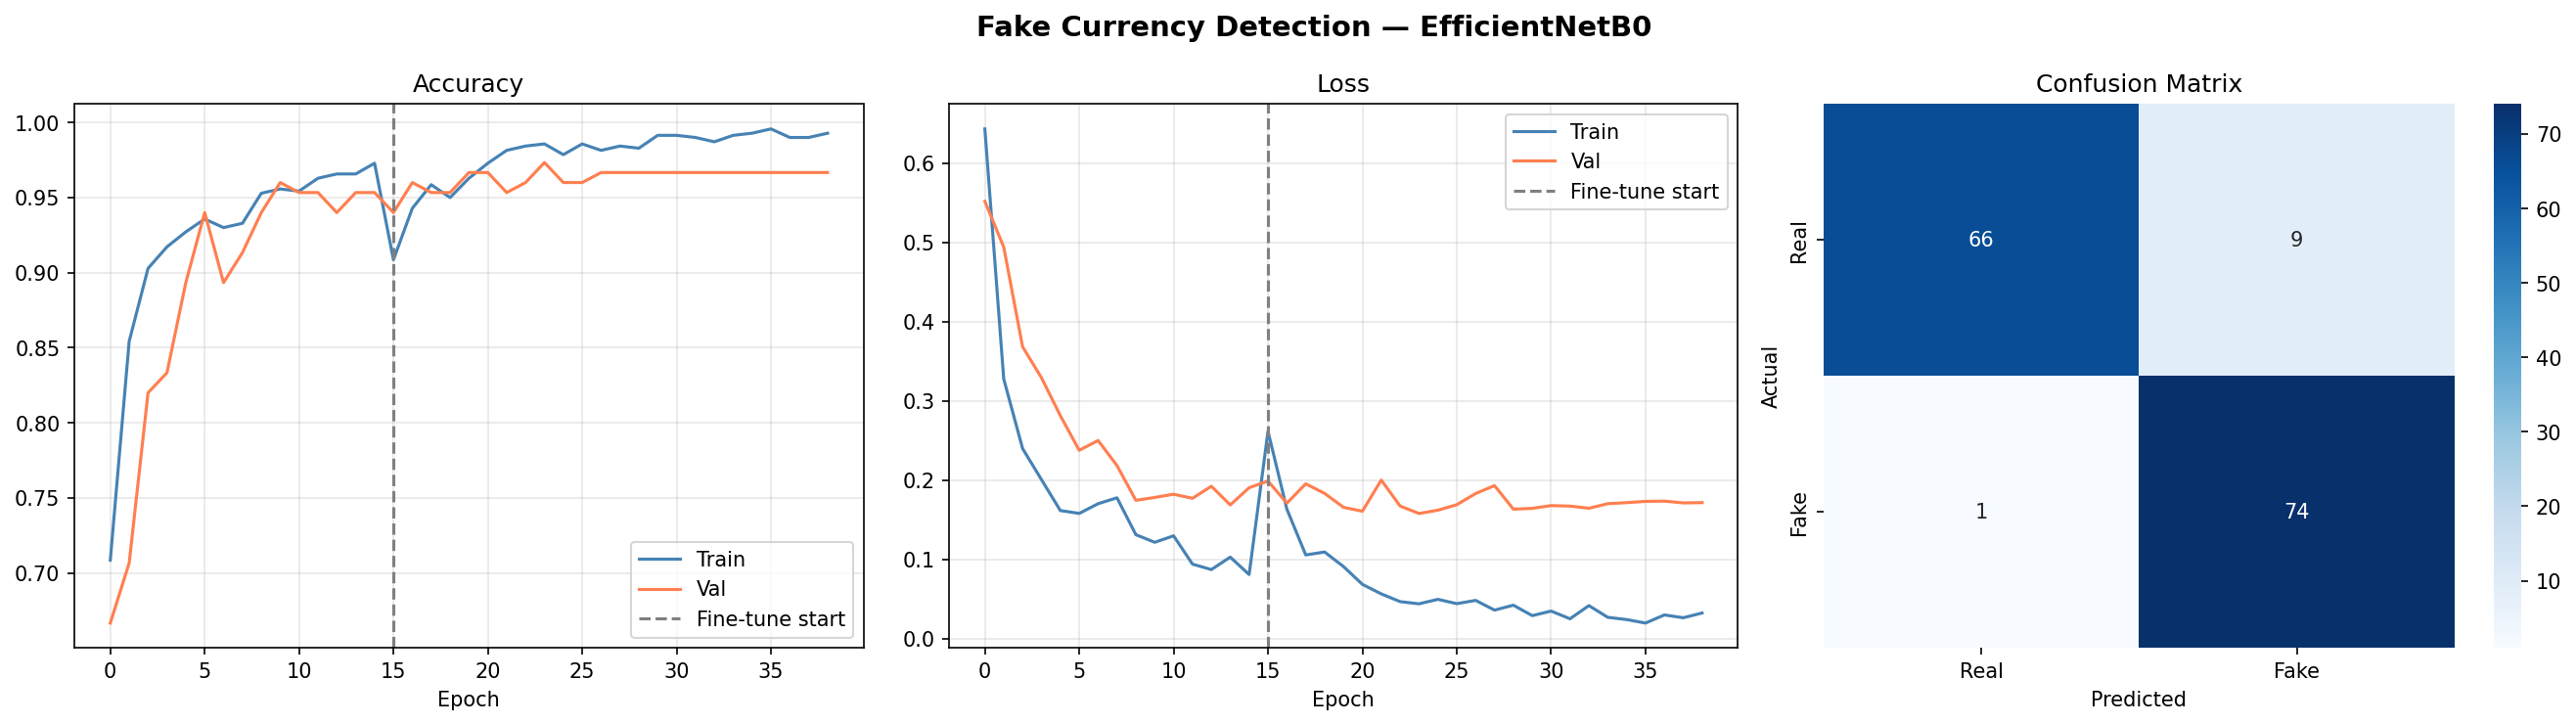

In [7]:
from IPython.display import Image
BASE = '/content/drive/MyDrive/FYP_FakeCurrency'
Image(f'{BASE}/model/training_results.png')

In [8]:
import os, shutil
BASE = '/content/drive/MyDrive/FYP_FakeCurrency'
APP  = '/content/fake_currency_app'

os.makedirs(f'{APP}/templates',      exist_ok=True)
os.makedirs(f'{APP}/static/uploads', exist_ok=True)
os.makedirs(f'{APP}/model',          exist_ok=True)

shutil.copy('/content/app.py', f'{APP}/app.py')

#  trained model into app folder
shutil.copy(f'{BASE}/model/currency_cnn.h5',
            f'{APP}/model/currency_cnn.h5')

print("App folder ready!")
shutil.copy('/content/index.html', f'{APP}/templates/index.html')

App folder ready!


'/content/fake_currency_app/templates/index.html'

In [9]:
import threading, time, os, subprocess

os.chdir('/content/fake_currency_app')

# ── Start Flask ────────────────────────────────────────────
def run_flask():
    os.system('python app.py')

t = threading.Thread(target=run_flask, daemon=True)
t.start()
time.sleep(3)
print("✓ Flask started on port 5000")

# ── Install cloudflared ────────────────────────────────────
print("Installing Cloudflare tunnel...")
os.system('wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared')
os.system('chmod +x cloudflared')
print("✓ Cloudflared installed")

# ── Start tunnel ───────────────────────────────────────────
print("Starting tunnel...")
def run_tunnel():
    os.system('./cloudflared tunnel --url http://localhost:5000 2>&1 | tee /tmp/tunnel.log')

t2 = threading.Thread(target=run_tunnel, daemon=True)
t2.start()

# Wait and extract URL from log
print("Getting public URL", end="")
url = None
for i in range(30):
    time.sleep(2)
    print(".", end="", flush=True)
    try:
        with open('/tmp/tunnel.log', 'r') as f:
            for line in f.readlines():
                if 'trycloudflare.com' in line:
                    # Extract URL from log line
                    parts = line.split()
                    for p in parts:
                        if 'trycloudflare.com' in p:
                            url = p.strip()
                            break
    except:
        pass
    if url:
        break

print()
print("=" * 50)
if url:
    print(f"  YOUR APP URL: {url}")
    print("  Open in any browser or phone!")
else:
    print("  URL not found yet — run the cell below")
print("=" * 50)

✓ Flask started on port 5000
Installing Cloudflare tunnel...
✓ Cloudflared installed
Starting tunnel...
Getting public URL.
  YOUR APP URL: trycloudflare.com...
  Open in any browser or phone!


In [10]:
# Read tunnel log and find URL manually
with open('/tmp/tunnel.log', 'r') as f:
    lines = f.readlines()

print("Looking for URL in tunnel log...")
for line in lines:
    if 'trycloudflare.com' in line or 'https://' in line:
        print(line.strip())

Looking for URL in tunnel log...
2026-06-12T15:59:56Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-06-12T15:59:56Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-06-12T16:00:00Z INF |  https://satellite-doors-personality-apparent.trycloudflare.com                            |
2026/06/12 16:00:00 failed to sufficiently increase receive buffer size (was: 208 kiB, wanted: 7168 kiB, got: 416 kiB). See https://github.com/quic-go/quic-go/wiki/UDP-

In [6]:
import os, shutil, threading, time

os.environ['CUDA_VISIBLE_DEVICES'] = '-1'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

BASE = '/content/drive/MyDrive/FYP_FakeCurrency'
APP  = '/content/fake_currency_app'

# ── Save app.py permanently to Drive ──────────────────────
with open(f'{BASE}/app.py', 'w') as f:
    f.write('''
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import uuid, traceback, numpy as np
from flask import Flask, request, render_template, jsonify
from PIL import Image
import tensorflow as tf

BASE_DIR      = os.path.dirname(os.path.abspath(__file__))
MODEL_PATH    = os.path.join(BASE_DIR, "model", "currency_cnn.h5")
UPLOAD_FOLDER = os.path.join(BASE_DIR, "static", "uploads")
os.makedirs(UPLOAD_FOLDER, exist_ok=True)

app = Flask(__name__)
app.config["UPLOAD_FOLDER"]      = UPLOAD_FOLDER
app.config["MAX_CONTENT_LENGTH"] = 16 * 1024 * 1024

model = None
try:
    model = tf.keras.models.load_model(MODEL_PATH)
    print("✓ Model loaded on CPU")
    print("  Input shape:", model.input_shape)
except Exception as e:
    print("✗ Model error:", e)

def preprocess(path):
    img = Image.open(path).convert("RGB").resize((224, 224))
    arr = np.array(img, dtype=np.float32)
    arr = tf.keras.applications.efficientnet.preprocess_input(arr)
    return np.expand_dims(arr, axis=0)

@app.errorhandler(Exception)
def handle_error(e):
    traceback.print_exc()
    return jsonify({"error": str(e)}), 500

@app.route("/")
def index():
    return render_template("index.html", model_loaded=(model is not None))

@app.route("/predict", methods=["POST"])
def predict():
    try:
        if "file" not in request.files:
            return jsonify({"error": "No file"}), 400
        file = request.files["file"]
        if file.filename == "":
            return jsonify({"error": "Empty filename"}), 400
        ext  = file.filename.rsplit(".", 1)[-1].lower()
        path = os.path.join(UPLOAD_FOLDER, f"{uuid.uuid4().hex}.{ext}")
        file.save(path)
        if model is None:
            return jsonify({"error": "Model not loaded"}), 500
        prob  = float(model.predict(preprocess(path), verbose=0)[0][0])
        label = "FAKE" if prob >= 0.5 else "REAL"
        conf  = prob*100 if prob >= 0.5 else (1-prob)*100
        return jsonify({
            "label"      : label,
            "confidence" : round(conf, 2),
            "fake_prob"  : round(prob*100, 2),
            "real_prob"  : round((1-prob)*100, 2),
            "risk_level" : "HIGH" if conf>=85 and label=="FAKE" else "MEDIUM",
            "image_url"  : f"/static/uploads/{os.path.basename(path)}"
        })
    except Exception as e:
        traceback.print_exc()
        return jsonify({"error": str(e)}), 500

@app.route("/api/health")
def health():
    return jsonify({"status":"ok","model_loaded":model is not None})

if __name__ == "__main__":
    app.run(debug=False, host="0.0.0.0", port=5000)
''')
print("✓ app.py saved to Drive permanently")

# ── Create templates folder inside Drive ──────────────────
os.makedirs(f'{BASE}/templates',      exist_ok=True)
os.makedirs(f'{BASE}/static/uploads', exist_ok=True)

# Move index.html into templates folder in Drive
if os.path.exists(f'{BASE}/index.html'):
    shutil.copy(f'{BASE}/index.html', f'{BASE}/templates/index.html')
    print("✓ index.html saved to Drive/templates permanently")

print()
print("Your Drive is now permanently organized:")
print(f"  {BASE}/")
print(f"    app.py")
print(f"    templates/index.html")
print(f"    static/uploads/")
print(f"    model/currency_cnn.h5")
print(f"    dataset/real/  (500 images)")
print(f"    dataset/fake/  (500 images)")

✓ app.py saved to Drive permanently
✓ index.html saved to Drive/templates permanently

Your Drive is now permanently organized:
  /content/drive/MyDrive/FYP_FakeCurrency/
    app.py
    templates/index.html
    static/uploads/
    model/currency_cnn.h5
    dataset/real/  (500 images)
    dataset/fake/  (500 images)


In [2]:
# CELL 1 - Mount Drive (30 seconds)
from google.colab import drive
drive.mount('/content/drive')
print("✓ Drive mounted")

Mounted at /content/drive
✓ Drive mounted


In [3]:
# CELL 2 - Install libraries (1 minute)
!pip install flask tensorflow pillow -q
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O /content/cloudflared
!chmod +x /content/cloudflared
print("✓ Ready")

✓ Ready


In [4]:
# CELL 3 - Start app directly from Drive (no copying needed)
import os, threading, time

os.environ['CUDA_VISIBLE_DEVICES'] = '-1'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

BASE = '/content/drive/MyDrive/FYP_FakeCurrency'

os.system("pkill -f 'python app.py' 2>/dev/null")
time.sleep(2)

# Run directly from Drive
os.chdir(BASE)

def run_flask():
    os.system('python app.py > /tmp/flask.log 2>&1')

threading.Thread(target=run_flask, daemon=True).start()

print("Loading model on CPU", end="")
for i in range(30):
    time.sleep(2)
    print(".", end="", flush=True)
    try:
        with open('/tmp/flask.log', 'r') as f:
            log = f.read()
            if 'Model loaded' in log or 'Running on' in log:
                print()
                print(log)
                break
            if 'error' in log.lower():
                print()
                print(log)
                break
    except:
        pass

# Cloudflare tunnel
def run_tunnel():
    os.system('/content/cloudflared tunnel --url http://localhost:5000 2>&1 | tee /tmp/tunnel.log')

threading.Thread(target=run_tunnel, daemon=True).start()

print("Getting URL", end="")
url = None
for i in range(30):
    time.sleep(2)
    print(".", end="", flush=True)
    try:
        with open('/tmp/tunnel.log', 'r') as f:
            for line in f.readlines():
                if 'trycloudflare.com' in line:
                    for p in line.split():
                        if 'trycloudflare.com' in p:
                            url = p.strip()
    except:
        pass
    if url:
        break

print()
print("=" * 50)
print(f"  YOUR APP URL: {url}")
print("  Open in any browser!")
print("=" * 50)

Loading model on CPU.........
✓ Model loaded on CPU
  Input shape: (None, 224, 224, 3)
 * Serving Flask app 'app'
 * Debug mode: off
INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://172.28.0.12:5000
INFO:werkzeug:Press CTRL+C to quit

Getting URL.
  YOUR APP URL: trycloudflare.com...
  Open in any browser!


In [5]:
# Read tunnel log and find URL manually
with open('/tmp/tunnel.log', 'r') as f:
    lines = f.readlines()

print("Looking for URL in tunnel log...")
for line in lines:
    if 'trycloudflare.com' in line or 'https://' in line:
        print(line.strip())

Looking for URL in tunnel log...
2026-06-12T16:17:46Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-06-12T16:17:46Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-06-12T16:17:50Z INF |  https://patents-shade-equity-laden.trycloudflare.com                                      |
2026/06/12 16:17:50 failed to sufficiently increase receive buffer size (was: 208 kiB, wanted: 7168 kiB, got: 416 kiB). See https://github.com/quic-go/quic-go/wiki/UDP-